In [2]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import snowflake.connector

pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

user=os.getenv("user")
password=os.getenv("password")
account=os.getenv("account")
warehouse=os.getenv("warehouse")         
database=os.getenv('database')
schema=os.getenv('schema')

In [5]:
conn = snowflake.connector.connect(
    user=user,
    password=password,
    account=account,  
    warehouse=warehouse,             
    database=database,
    schema=schema
)

In [6]:
try:
    cursor = conn.cursor()

    cursor.execute("select * from taxi_trips")

    df = cursor.fetch_pandas_all()

    print(df.head())

finally:
    cursor.close()
    conn.close()

   VENDORID  TPEP_PICKUP_DATETIME  TPEP_DROPOFF_DATETIME  PASSENGER_COUNT  \
0         1      1675268251000000       1675268615000000            1.000   
1         2      1675269076000000       1675270076000000            1.000   
2         2      1675268151000000       1675268714000000            1.000   
3         1      1675267285000000       1675267590000000            2.000   
4         2      1675270333000000       1675271794000000            5.000   

   TRIP_DISTANCE  RATECODEID STORE_AND_FWD_FLAG  PULOCATIONID  DOLOCATIONID  \
0          0.800       1.000                  N           113           158   
1          2.450       1.000                  N           170           249   
2          1.040       1.000                  N           244           243   
3          0.700       1.000                  N           237           229   
4          3.470       1.000                  N           140            24   

   PAYMENT_TYPE  FARE_AMOUNT  EXTRA  MTA_TAX  TIP_AMOUNT  TOLL

In [7]:
df.head()

,VENDORID,TPEP_PICKUP_DATETIME,TPEP_DROPOFF_DATETIME,PASSENGER_COUNT,TRIP_DISTANCE,RATECODEID,STORE_AND_FWD_FLAG,PULOCATIONID,DOLOCATIONID,PAYMENT_TYPE,FARE_AMOUNT,EXTRA,MTA_TAX,TIP_AMOUNT,TOLLS_AMOUNT,IMPROVEMENT_SURCHARGE,TOTAL_AMOUNT,CONGESTION_SURCHARGE,AIRPORT_FEE,ABS_FARE,ABS_TOTAL,PICKUP_MONTH,PICKUP_DAY,PICKUP_HOUR,PICKUP_DAY_OF_WEEK_NUM,PICKUP_DAY_OF_WEEK,PICKUP_DATE,IS_WEEKEND,TRIP_DURATION_MINUTES,PICKUP_DATETIME,DROPOFF_DATETIME
0,1,1675268251000000,1675268615000000,1.000,0.800,1.000,N,113,158,1,7.200,5.000,0.500,2.700,0.000,1.000,16.400,2.500,0.000,7.200,16.400,2,1,16,2,Wednesday,2023-02-01,False,6.067,2023-02-01 16:17:31,2023-02-01 16:23:35
1,2,1675269076000000,1675270076000000,1.000,2.450,1.000,N,170,249,1,16.300,2.500,0.500,4.560,0.000,1.000,27.360,2.500,0.000,16.300,27.360,2,1,16,2,Wednesday,2023-02-01,False,16.667,2023-02-01 16:31:16,2023-02-01 16:47:56
2,2,1675268151000000,1675268714000000,1.000,1.040,1.000,N,244,243,1,10.000,0.000,0.500,2.690,0.000,1.000,16.140,0.000,0.000,10.000,16.140,2,1,16,2,Wednesday,2023-02-01,False,9.383,2023-02-01 16:15:51,2023-02-01 16:25:14
3,1,1675267285000000,1675267590000000,2.000,0.700,1.000,N,237,229,2,6.500,5.000,0.500,0.000,0.000,1.000,13.000,2.500,0.000,6.500,13.000,2,1,16,2,Wednesday,2023-02-01,False,5.083,2023-02-01 16:01:25,2023-02-01 16:06:30
4,2,1675270333000000,1675271794000000,5.000,3.470,1.000,N,140,24,2,23.300,2.500,0.500,0.000,0.000,1.000,29.800,2.500,0.000,23.300,29.800,2,1,16,2,Wednesday,2023-02-01,False,24.350,2023-02-01 16:52:13,2023-02-01 17:16:34


In [12]:
location_key = pd.read_csv('../taxi_zone_lookup.csv')

In [13]:
location_key

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
...,...,...,...,...
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NaN,NaN


In [15]:
head = df.head()

In [26]:
df = df\
    .merge(location_key, how='left', left_on='PULOCATIONID', right_on='LocationID')\
    .rename(columns={'Borough': 'PUBOROUGH', 'Zone': 'PUZONE', 'service_zone': 'PUSERVICEZONE'})\
    .drop(columns='LocationID')\
    .merge(location_key, how='left', left_on='DOLOCATIONID', right_on='LocationID')\
    .rename(columns={'Borough': 'DOBOROUGH', 'Zone': 'DOZONE', 'service_zone': 'DOSERVICEZONE'})\
    .drop(columns='LocationID')

In [27]:
df.head()

,VENDORID,TPEP_PICKUP_DATETIME,TPEP_DROPOFF_DATETIME,PASSENGER_COUNT,TRIP_DISTANCE,RATECODEID,STORE_AND_FWD_FLAG,PULOCATIONID,DOLOCATIONID,PAYMENT_TYPE,FARE_AMOUNT,EXTRA,MTA_TAX,TIP_AMOUNT,TOLLS_AMOUNT,IMPROVEMENT_SURCHARGE,TOTAL_AMOUNT,CONGESTION_SURCHARGE,AIRPORT_FEE,ABS_FARE,ABS_TOTAL,PICKUP_MONTH,PICKUP_DAY,PICKUP_HOUR,PICKUP_DAY_OF_WEEK_NUM,PICKUP_DAY_OF_WEEK,PICKUP_DATE,IS_WEEKEND,TRIP_DURATION_MINUTES,PICKUP_DATETIME,DROPOFF_DATETIME,PUBOROUGH,PUZONE,PUSERVICEZONE,DOBOROUGH,DOZONE,DOSERVICEZONE
0,1,1675268251000000,1675268615000000,1.000,0.800,1.000,N,113,158,1,7.200,5.000,0.500,2.700,0.000,1.000,16.400,2.500,0.000,7.200,16.400,2,1,16,2,Wednesday,2023-02-01,False,6.067,2023-02-01 16:17:31,2023-02-01 16:23:35,Manhattan,Greenwich Village North,Yellow Zone,Manhattan,Meatpacking/West Village West,Yellow Zone
1,2,1675269076000000,1675270076000000,1.000,2.450,1.000,N,170,249,1,16.300,2.500,0.500,4.560,0.000,1.000,27.360,2.500,0.000,16.300,27.360,2,1,16,2,Wednesday,2023-02-01,False,16.667,2023-02-01 16:31:16,2023-02-01 16:47:56,Manhattan,Murray Hill,Yellow Zone,Manhattan,West Village,Yellow Zone
2,2,1675268151000000,1675268714000000,1.000,1.040,1.000,N,244,243,1,10.000,0.000,0.500,2.690,0.000,1.000,16.140,0.000,0.000,10.000,16.140,2,1,16,2,Wednesday,2023-02-01,False,9.383,2023-02-01 16:15:51,2023-02-01 16:25:14,Manhattan,Washington Heights South,Boro Zone,Manhattan,Washington Heights North,Boro Zone
3,1,1675267285000000,1675267590000000,2.000,0.700,1.000,N,237,229,2,6.500,5.000,0.500,0.000,0.000,1.000,13.000,2.500,0.000,6.500,13.000,2,1,16,2,Wednesday,2023-02-01,False,5.083,2023-02-01 16:01:25,2023-02-01 16:06:30,Manhattan,Upper East Side South,Yellow Zone,Manhattan,Sutton Place/Turtle Bay North,Yellow Zone
4,2,1675270333000000,1675271794000000,5.000,3.470,1.000,N,140,24,2,23.300,2.500,0.500,0.000,0.000,1.000,29.800,2.500,0.000,23.300,29.800,2,1,16,2,Wednesday,2023-02-01,False,24.350,2023-02-01 16:52:13,2023-02-01 17:16:34,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Bloomingdale,Yellow Zone


In [28]:
df['PUBOROUGH'].value_counts()

PUBOROUGH
Manhattan        31530392
Queens            3555154
Unknown            340521
Brooklyn           199831
Bronx               58501
EWR                  4668
Staten Island        2340
Name: count, dtype: int64

In [29]:
df.isna().sum()

VENDORID                       0
TPEP_PICKUP_DATETIME           0
TPEP_DROPOFF_DATETIME          0
PASSENGER_COUNT                0
TRIP_DISTANCE                  0
RATECODEID                     0
STORE_AND_FWD_FLAG             0
PULOCATIONID                   0
DOLOCATIONID                   0
PAYMENT_TYPE                   0
FARE_AMOUNT                    0
EXTRA                          0
MTA_TAX                        0
TIP_AMOUNT                     0
TOLLS_AMOUNT                   0
IMPROVEMENT_SURCHARGE          0
TOTAL_AMOUNT                   0
CONGESTION_SURCHARGE           0
AIRPORT_FEE                    0
ABS_FARE                       0
ABS_TOTAL                      0
PICKUP_MONTH                   0
PICKUP_DAY                     0
PICKUP_HOUR                    0
PICKUP_DAY_OF_WEEK_NUM         0
PICKUP_DAY_OF_WEEK             0
PICKUP_DATE                    0
IS_WEEKEND                     0
TRIP_DURATION_MINUTES          0
PICKUP_DATETIME                0
DROPOFF_DA

## Understanding the Dataset

In [31]:
df.shape

(35710902, 37)

> There are 35.7M rows in this dataset spaning across all 12 months in 2023.
>
> We have 37 columns of data to work with, most are from the original dataset, but others, such as pickup date, month, hour, and trip duration were created in the data cleaning/transformation steps. We also added the location information for pickup and dropoff above. 

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35710902 entries, 0 to 35710901
Data columns (total 37 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   VENDORID                int8          
 1   TPEP_PICKUP_DATETIME    int64         
 2   TPEP_DROPOFF_DATETIME   int64         
 3   PASSENGER_COUNT         float64       
 4   TRIP_DISTANCE           float64       
 5   RATECODEID              float64       
 6   STORE_AND_FWD_FLAG      object        
 7   PULOCATIONID            int16         
 8   DOLOCATIONID            int16         
 9   PAYMENT_TYPE            int8          
 10  FARE_AMOUNT             float64       
 11  EXTRA                   float64       
 12  MTA_TAX                 float64       
 13  TIP_AMOUNT              float64       
 14  TOLLS_AMOUNT            float64       
 15  IMPROVEMENT_SURCHARGE   float64       
 16  TOTAL_AMOUNT            float64       
 17  CONGESTION_SURCHARGE    float64       
 18  

In [30]:
df.describe()

,VENDORID,TPEP_PICKUP_DATETIME,TPEP_DROPOFF_DATETIME,PASSENGER_COUNT,TRIP_DISTANCE,RATECODEID,PULOCATIONID,DOLOCATIONID,PAYMENT_TYPE,FARE_AMOUNT,EXTRA,MTA_TAX,TIP_AMOUNT,TOLLS_AMOUNT,IMPROVEMENT_SURCHARGE,TOTAL_AMOUNT,CONGESTION_SURCHARGE,AIRPORT_FEE,ABS_FARE,ABS_TOTAL,PICKUP_MONTH,PICKUP_DAY,PICKUP_HOUR,PICKUP_DAY_OF_WEEK_NUM,TRIP_DURATION_MINUTES,PICKUP_DATETIME,DROPOFF_DATETIME
count,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902.000,35710902,35710902
mean,1.749,1688251866060996.250,1688252917214273.750,1.393,3.472,1.659,165.386,164.291,1.184,19.863,1.610,0.495,3.626,0.605,0.999,29.056,2.311,0.144,19.863,29.056,6.512,15.504,14.301,2.995,17.519,2023-07-01 22:51:06.060996,2023-07-01 23:08:37.214273
min,1.000,1672531205000000.000,1672531408000000.000,1.000,0.000,1.000,1.000,1.000,1.000,0.000,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,2023-01-01 00:00:05,2023-01-01 00:03:28
25%,1.000,1680379856000000.000,1680380802000000.000,1.000,1.060,1.000,132.000,114.000,1.000,9.300,0.000,0.500,1.000,0.000,1.000,15.960,2.500,0.000,9.300,15.960,4.000,8.000,11.000,1.000,7.650,2023-04-01 20:10:56,2023-04-01 20:26:42
50%,2.000,1687775965500000.000,1687777019000000.000,1.000,1.800,1.000,162.000,162.000,1.000,13.500,1.000,0.500,2.880,0.000,1.000,21.000,2.500,0.000,13.500,21.000,6.000,15.000,15.000,3.000,12.617,2023-06-26 10:39:25.500000,2023-06-26 10:56:59
75%,2.000,1696540638000000.000,1696541595000000.000,1.000,3.400,1.000,234.000,234.000,1.000,21.900,2.500,0.500,4.480,0.000,1.000,30.800,2.500,0.000,21.900,30.800,10.000,23.000,19.000,5.000,20.617,2023-10-05 21:17:18,2023-10-05 21:33:15
max,2.000,1704067199000000.000,1704226405000000.000,9.000,99.920,99.000,265.000,265.000,5.000,386983.630,10002.500,53.160,984.300,665.560,1.000,386987.630,2.750,1.750,386983.630,386987.630,12.000,31.000,23.000,6.000,10029.183,2023-12-31 23:59:59,2024-01-02 20:13:25
std,0.433,9119484734831.439,9119528947965.600,0.884,4.556,7.548,63.678,69.795,0.411,78.104,2.479,0.050,4.113,2.196,0.024,79.420,0.661,0.466,78.104,79.420,3.464,8.699,5.779,1.928,42.267,NaN,NaN


### Summary Statistics

| Column | Average | Median | Insights | 
| ------ | ------- | ------ | -------- |
| Fare Amount | \$19.86 | \$13.50 | As the mean is higher than the median, there is a slight rightward skew in the data. We will confirm this with visualiations later. |
| Total Amount | \$29.06 | \$21.00 | Same as Fare Amount, there may be a slight right skew |
| Trip Distance (Miles) | 3.47 | 1.8 | During cleaning process, we did remove trips greater than 100 miles, as these are abnormalities. |
| Passenger Count | 1.39 | 1 | Most trips only had one passenger |
| Trip Duration (minutes) | 17.52 | 12.62 | This is also right skewed slightly as the mean is higher than the median | 


## Trip Behavior

In [33]:
df['TRIP_DURATION_MINUTES'].describe()

count   35710902.000
mean          17.519
std           42.267
min            0.000
25%            7.650
50%           12.617
75%           20.617
max        10029.183
Name: TRIP_DURATION_MINUTES, dtype: float64

<Axes: xlabel='TRIP_DURATION_MINUTES', ylabel='Count'>

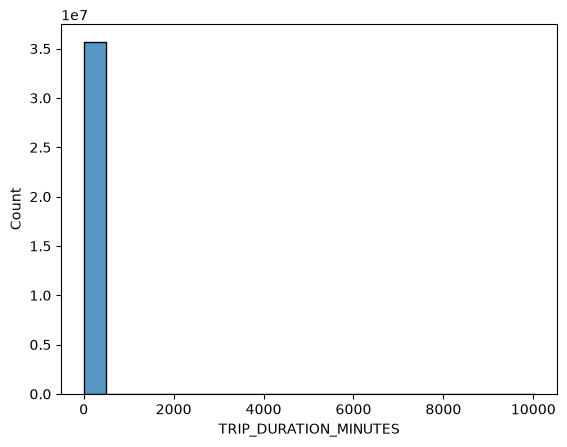

In [37]:
sns.histplot(data=df, x='TRIP_DURATION_MINUTES', bins=20)

In [42]:
# sns.histplot(x=np.log(df['TRIP_DURATION_MINUTES']), bins=20)

Let's look at the 20 longest trips to see if we can uncover outliers missed during the original cleaning

In [45]:
df.nlargest(
    20,
    "TRIP_DURATION_MINUTES"
)[[
    "PICKUP_DATETIME",
    "DROPOFF_DATETIME",
    "TRIP_DURATION_MINUTES",
    "TRIP_DISTANCE",
    "FARE_AMOUNT",
    "TOTAL_AMOUNT"
]]

,PICKUP_DATETIME,DROPOFF_DATETIME,TRIP_DURATION_MINUTES,TRIP_DISTANCE,FARE_AMOUNT,TOTAL_AMOUNT
22981989,2023-01-23 11:21:51,2023-01-30 10:31:02,10029.183,0.000,3.000,4.500
29774108,2023-05-24 12:51:56,2023-05-31 11:19:03,9987.117,0.000,3.000,4.500
28861342,2023-08-16 08:19:21,2023-08-22 16:36:26,9137.083,0.000,3.000,4.500
20199236,2023-08-02 11:05:52,2023-08-08 17:20:46,9014.900,0.000,3.700,5.200
33521860,2023-08-31 08:33:05,2023-09-05 11:05:12,7352.117,0.000,3.000,4.500
21597318,2023-07-14 12:52:23,2023-07-19 15:21:13,7348.833,0.000,3.000,4.500
19944798,2023-08-16 10:56:52,2023-08-21 12:03:43,7266.850,0.000,3.000,4.500
35071153,2023-12-15 11:42:05,2023-12-20 11:30:24,7188.317,0.000,4.400,5.900
689385,2023-02-23 14:59:05,2023-02-28 12:32:42,7053.617,14.340,80.000,82.750
11266095,2023-08-28 18:13:03,2023-09-02 10:57:12,6764.150,0.670,14.200,20.700


In [51]:
df.nlargest(
    5,
    "TRIP_DURATION_MINUTES"
)[[
    "PICKUP_DATETIME",
    "DROPOFF_DATETIME",
    "TRIP_DURATION_MINUTES",
    "TRIP_DISTANCE",
    "FARE_AMOUNT",
    "TOTAL_AMOUNT"
]]

,PICKUP_DATETIME,DROPOFF_DATETIME,TRIP_DURATION_MINUTES,TRIP_DISTANCE,FARE_AMOUNT,TOTAL_AMOUNT
22981989,2023-01-23 11:21:51,2023-01-30 10:31:02,10029.183,0.000,3.000,4.500
29774108,2023-05-24 12:51:56,2023-05-31 11:19:03,9987.117,0.000,3.000,4.500
28861342,2023-08-16 08:19:21,2023-08-22 16:36:26,9137.083,0.000,3.000,4.500
20199236,2023-08-02 11:05:52,2023-08-08 17:20:46,9014.900,0.000,3.700,5.200
33521860,2023-08-31 08:33:05,2023-09-05 11:05:12,7352.117,0.000,3.000,4.500


In [46]:
df["TRIP_DURATION_MINUTES"].describe(
    percentiles=[.50,.75,.90,.95,.99,.999]
)

count   35710902.000
mean          17.519
std           42.267
min            0.000
50%           12.617
75%           20.617
90%           32.583
95%           43.283
99%           67.967
99.9%        159.202
max        10029.183
Name: TRIP_DURATION_MINUTES, dtype: float64

In [47]:
p99 = df["TRIP_DURATION_MINUTES"].quantile(.99)

df_filtered = df[
    df["TRIP_DURATION_MINUTES"] <= p99
]

<Axes: xlabel='TRIP_DURATION_MINUTES', ylabel='Count'>

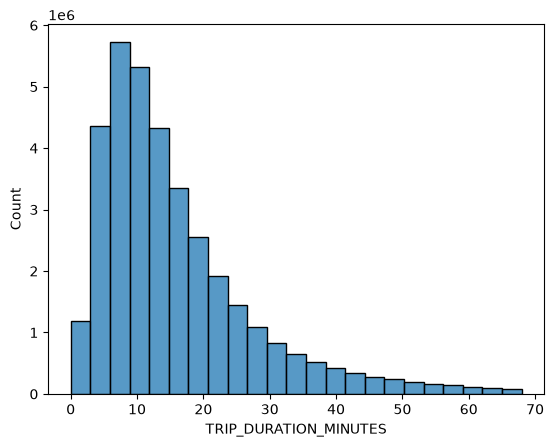

In [50]:
sns.histplot(data=df_filtered, x='TRIP_DURATION_MINUTES', binwidth=3)

In [52]:
df[
    (df["TRIP_DURATION_MINUTES"] > 240)
].shape

(33065, 37)

In [53]:
df[
    (df["TRIP_DURATION_MINUTES"] > 240)
]["TRIP_DURATION_MINUTES"].describe()

count   33065.000
mean     1277.951
std       385.119
min       240.133
25%      1384.617
50%      1419.833
75%      1433.033
max     10029.183
Name: TRIP_DURATION_MINUTES, dtype: float64

In [54]:
df_filtered["TRIP_DURATION_MINUTES"].describe(
    percentiles=[.50,.75,.90,.95,.99,.999]
)

count   35353941.000
mean          15.751
std           11.683
min            0.000
50%           12.500
75%           20.267
90%           31.350
95%           40.517
99%           57.683
99.9%         66.567
max           67.967
Name: TRIP_DURATION_MINUTES, dtype: float64

> There are around 33K+ rows that have trip durations over 4 hours. Looking at the 20 longest trips, many of them went on for days, but had a distance of 0 and very low fares. These are likely data entry errors and so were excluded from the visualization and analysis by limiting it to the 99th percentile ,which is just over an hour. 

### Key Findings

- Median trip duration was 12.5 minutes.
- 95% of trips were shorter than 40.5 minutes.
- Several duration outliers spanning multiple days were identified.
- These outliers were associated with zero-distance, minimum-fare trips.
- A histogram of the rows up to the 99th percentile for duration was generated, and was found to be right skewed
- The majority of trips were between 5 and 20 minutes. 

## Duration Analysis Findings

- Median trip duration: 12.6 minutes
- Mean trip duration: 17.5 minutes
- Extreme duration outliers exist
- Top duration outliers have:
    - 0 trip distance
    - minimum fares (~$3-$5)
    - durations spanning multiple days
- Further investigation required before establishing a duration cleaning rule

## Next Session

1. Investigate highest fare amounts
2. Investigate highest total amounts
3. Calculate 90th/95th/99th duration percentiles
4. Determine additional cleaning rules
5. Continue trip distance EDA